# Class Test 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Question 3
### (a)

In [2]:
#setting up variables
m = 1.0
V1 = 3.0
V2 = 5.0
sig1 = 0.5
sig2 = 0.4
b = 1
gamma = 0.3
x0 = -0.5
v0 = 2.0


In [3]:
# DEfining functions
def F(x):    #this is -dV/dx 
    return -((V1*(x+b)/(sig1**2))*np.exp(-((x+b)**2)/(2*sig1**2))) - ((V2*(x-b)/(sig2**2))*np.exp(-((x-b)**2)/(2*sig2**2)))

def V(x):
    return (V1*np.exp(-((x+b)**2)/(2*sig1**2))) + (V2*np.exp(-((x-b)**2)/(2*sig2**2)))

print(f"V(x0) = {V(x0)}")
E0 = (0.5*m*v0*v0)+V(x0)
print(f"E0 = {E0}")
xfine = np.arange(-3, 3, 10e-3)

#def system

V(x0) = 1.8240111106725756
E0 = 3.8240111106725756


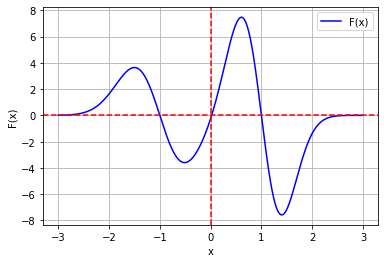

In [4]:
# Plotting F(x)
Ffine = np.array(F(xfine))
plt.xlabel("x")
plt.ylabel("F(x)")
plt.plot(xfine, Ffine, color="blue", label="F(x)")
plt.axhline(0, color = "red",linestyle = "--")
plt.axvline(0, color = "red",linestyle = "--")
plt.grid()
plt.legend()

Depth at 0, V(0)= 0.6256905178268752
Height difference between right and left wall = 2.000987754617847


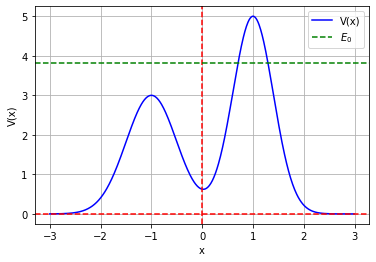

In [5]:
# Plotting V(x)
Vfine = np.array(V(xfine))
plt.xlabel("x")
plt.ylabel("V(x)")
plt.plot(xfine, Vfine, color="blue", label="V(x)")
plt.axhline(0, color = "red",linestyle = "--")
plt.axvline(0, color = "red",linestyle = "--")
plt.axhline(E0, color = "green",linestyle = "--", label="$E_0$")
plt.grid()
plt.legend()

print(f"Depth at 0, V(0)= {V(0)}")
print(f"Height difference between right and left wall = {V(1)-V(-1)}")
# as we can see, Both Peaks are located on exactly -1 and +1 because the derivatives (Force) becomes zero at those exact points. 
#the other point where F(x) becoms zero is x=0, showing it is the local minima
#height of hills are 3 and 5 for left and right respectively.

## (b)

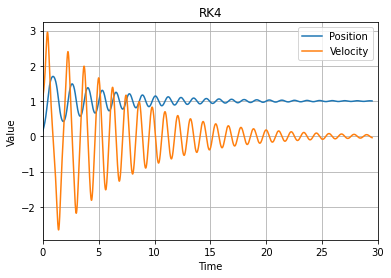

In [6]:
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller(my_method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = my_method(fn, x, y, h)
    return ys

def g(t, y):
    return np.asarray([y[1], (1/m)*(F(y[0])-(gamma*y[1]))])


h = 10e-3
N = 3000
xarr = np.arange(x0, x0 + N * h, h)
y_ini = np.asarray([x0, v0])
ysrk4 = caller(rk4, g, y_ini, N, xarr, h)

# Plot for RK4 method
plt.plot(xarr, ysrk4[:, 0], label="Position")
plt.plot(xarr, ysrk4[:, 1], label="Velocity")
plt.xlim([0.0, 30.0])
plt.title("RK4")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid()



# The particle is Oscillating from right to left wall and the oscillation is damping.
# The velocity changes sign at approx 1.4, 2.7,....seconds


 The spiral goes towards the fixed point which represents the equilibrium state of the particle while it has no velocity and it becomes still


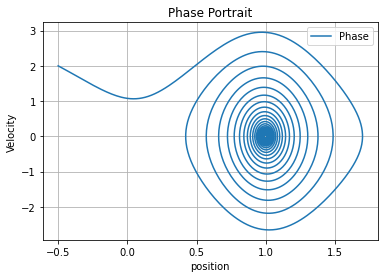

In [7]:
# Phase portrait:
plt.plot(ysrk4[:, 0],ysrk4[:, 1], label="Phase")
plt.title("Phase Portrait")
plt.legend()
plt.xlabel("position")
plt.ylabel("Velocity")
plt.grid()

print(" The spiral goes towards the fixed point which represents the equilibrium state of the particle while it has no velocity and it becomes still")

## (c)

In [8]:
def bisection(f,Left_edge,Right_edge,eps,maxiter):
    if f(Left_edge)*f(Right_edge) > 0.0:
        print('bad interval')
        return None
    else:
        roots = [i for i in (Left_edge,Right_edge) if abs(f(i))<=eps]
        if len(roots)>0:
            print('bracketing edges contain roots')
            return roots
        print('Employing bisection')
        Centre = (Left_edge + Right_edge)/2
        iter = 1
        while abs(f(Centre))>eps and iter<maxiter:
            #print(iter, Centre)
            if f(Left_edge)*f(Centre)>0.0:
                Left_edge = Centre
            else:
                Right_edge = Centre
            Centre = (Left_edge+Right_edge)/2
            iter += 1
        if iter==maxiter and abs(f(Centre))>eps:
            print('did not converge')
            return None
        return iter, Centre

## (d)

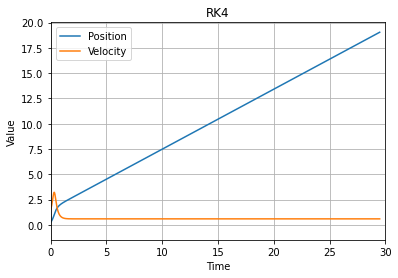

In [9]:
# for lower drag
gamma = 0.0
def g(t, y):
    return np.asarray([y[1], (1/m)*(F(y[0])-(gamma*y[1]))])

h = 10e-3
N = 3000
xarr = np.arange(x0, x0 + N * h, h)
y_ini = np.asarray([x0, v0])
ysrk4 = caller(rk4, g, y_ini, N, xarr, h)

# Plot for RK4 method
plt.plot(xarr, ysrk4[:, 0], label="Position")
plt.plot(xarr, ysrk4[:, 1], label="Velocity")
plt.xlim([0.0, 30.0])
plt.title("RK4")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid()



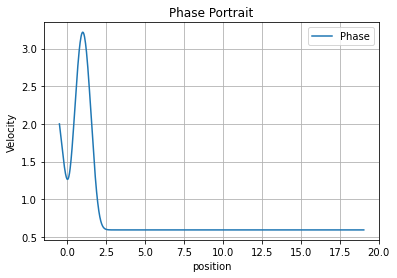

In [10]:
# Phase portrait:
plt.plot(ysrk4[:, 0],ysrk4[:, 1], label="Phase")
plt.title("Phase Portrait")
plt.legend()
plt.xlabel("position")
plt.ylabel("Velocity")
plt.grid()


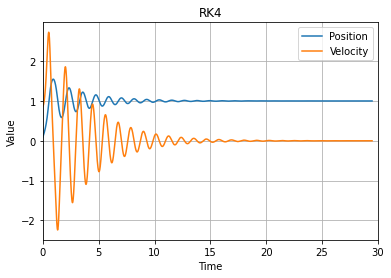

In [11]:
# for higher drag
gamma = 0.6
def g(t, y):
    return np.asarray([y[1], (1/m)*(F(y[0])-(gamma*y[1]))])

h = 10e-3
N = 3000
xarr = np.arange(x0, x0 + N * h, h)
y_ini = np.asarray([x0, v0])
ysrk4 = caller(rk4, g, y_ini, N, xarr, h)

# Plot for RK4 method
plt.plot(xarr, ysrk4[:, 0], label="Position")
plt.plot(xarr, ysrk4[:, 1], label="Velocity")
plt.xlim([0.0, 30.0])
plt.title("RK4")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid()


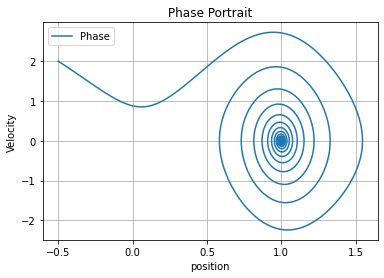

In [12]:
# Phase portrait:
plt.plot(ysrk4[:, 0],ysrk4[:, 1], label="Phase")
plt.title("Phase Portrait")
plt.legend()
plt.xlabel("position")
plt.ylabel("Velocity")
plt.grid()


# Q4

In [13]:
V0 = 10
a = 5

def odef():

def potential(x):
    if x < a2:
        return (-1*V0*squrt(a2*a2+x*x))
    return 0

IndentationError: expected an indented block after function definition on line 4 (3776649620.py, line 6)